Descargando datos para: ['QQQ', 'DBC', 'XLE', 'GLD', 'TLT']...
Iniciando Backtest Rolling (215 periodos)...


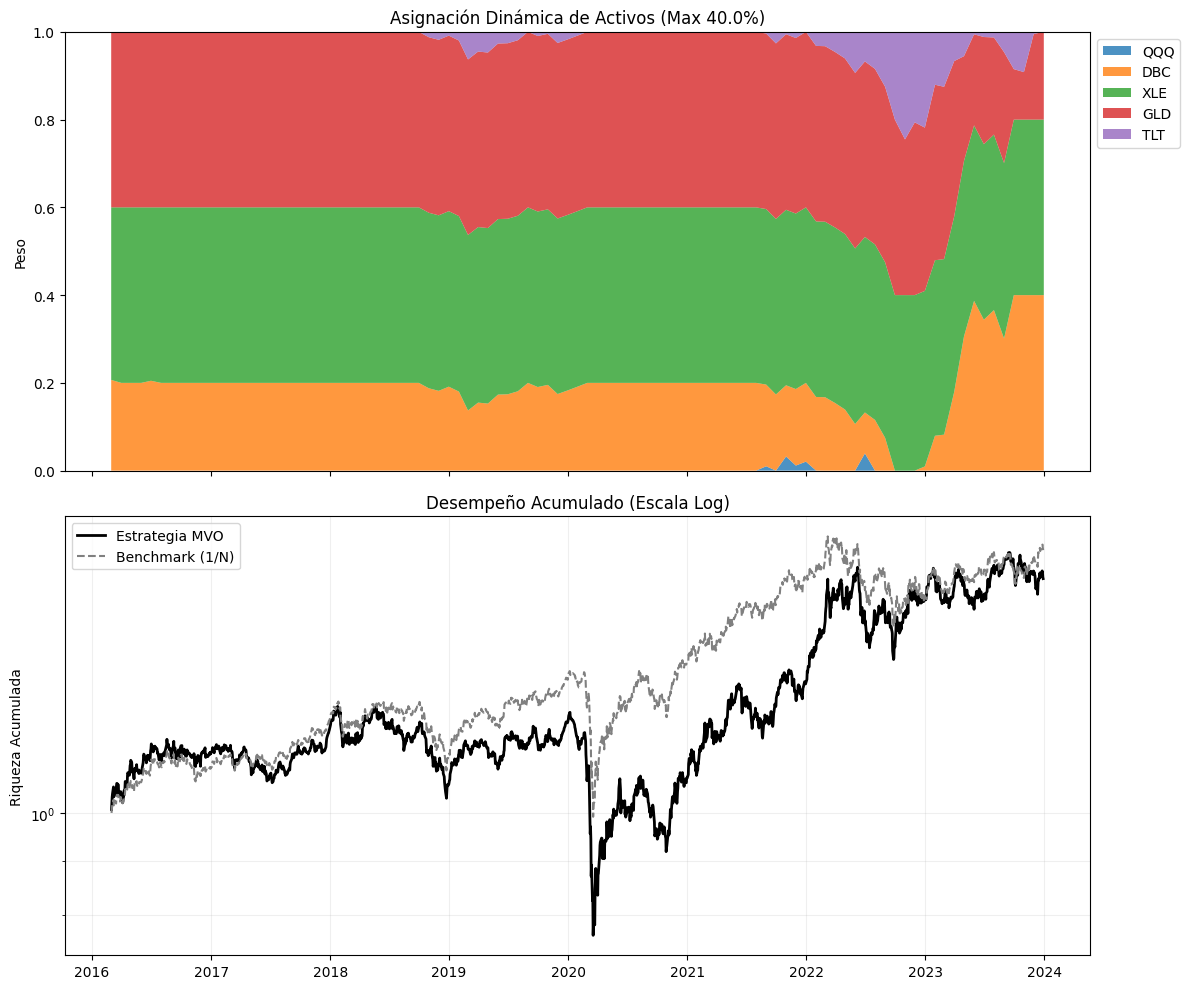

Retorno Total: 66.51%
Volatilidad Anual: 16.44%
Sharpe Ratio (ex-post): 0.48


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.optimize as sco
import matplotlib.pyplot as plt
import warnings

# Silenciar advertencias de pandas (común en versiones recientes con yfinance)
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. Configuración Robusta
# ------------------------
ASSETS = ['QQQ', 'DBC', 'XLE', 'GLD', 'TLT']
START_DATE = '1990-01-01'
END_DATE = '2024-01-01'

# Parámetros de Estrategia
LOOKBACK_YEARS = 10         # Ventana rodante para estimación de parámetros
REBALANCE_FREQ = 'ME'      # Rebalanceo a fin de mes
MAX_ALLOCATION = 0.40      # Restricción: Ningún activo > 40% (evita esquinas)
TRADING_DAYS = 252

def get_data_correctly(assets, start, end):
    """
    Descarga precios y ajusta dimensionalmente la tasa libre de riesgo.
    """
    print(f"Descargando datos para: {assets}...")
    data = yf.download(assets, start=start, end=end, progress=False, auto_adjust=False)['Adj Close']
    
    # Cálculo de Log Retornos
    returns = np.log(data / data.shift(1)).dropna()
    
    # Descarga y ajuste de Tasa Libre de Riesgo (^TNX)
    # TNX es yield anual x 10 (ej. 40.0 = 4.0%). A veces es directo %.
    # Asumimos que yfinance devuelve ej 4.2 para 4.2%.
    tnx = yf.download("^TNX", start=start, end=end, progress=False, auto_adjust=False)['Adj Close']
    
    # Paso 1: Convertir a decimal (4.2 -> 0.042)
    tnx = tnx / 100.0 
    
    # Paso 2: Alinear con el índice de los activos
    tnx = tnx.reindex(returns.index).ffill().fillna(0.04) # Fillna con 4% si falta data al inicio
    
    # Paso 3: DESANUALIZAR (Conversión Geométrica a Tasa Diaria)
    # (1 + r_anual)^(1/252) - 1
    rf_daily = (1 + tnx) ** (1/TRADING_DAYS) - 1
    
    # Si rf_daily es una Serie de una sola columna, aseguramos que sea Series de pandas
    if isinstance(rf_daily, pd.DataFrame):
        rf_daily = rf_daily.iloc[:, 0]
        
    return returns, rf_daily

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, current_rf):
    """
    Función objetivo para minimizar (-Sharpe).
    Usamos inputs pre-calculados (media y covarianza) para velocidad.
    """
    portfolio_ret = np.sum(mean_returns * weights) * TRADING_DAYS
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(TRADING_DAYS)
    
    # Sharpe = (Rp - Rf) / Sigma
    # Usamos la Rf actual anualizada para el cálculo del Sharpe Ex-Ante
    rf_annual = (1 + current_rf)**TRADING_DAYS - 1
    
    return - (portfolio_ret - rf_annual) / portfolio_vol

def optimize_portfolio(sub_returns, current_rf_daily):
    """
    Optimización de Media-Varianza con restricciones.
    """
    num_assets = sub_returns.shape[1]
    
    # Estadísticos muestrales (Inputs del optimizador)
    mean_returns = sub_returns.mean()
    cov_matrix = sub_returns.cov()
    
    args = (mean_returns, cov_matrix, current_rf_daily)
    
    # Restricción 1: Suma de pesos = 1
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    # Restricción 2: Límites por activo (0 <= w <= MAX_ALLOCATION)
    # Esto fuerza diversificación.
    bounds = tuple((0.0, MAX_ALLOCATION) for _ in range(num_assets))
    
    init_guess = num_assets * [1. / num_assets,]
    
    try:
        result = sco.minimize(neg_sharpe_ratio, init_guess, args=args,
                              method='SLSQP', bounds=bounds, constraints=constraints,
                              tol=1e-6)
        return result.x
    except Exception as e:
        # Fallback en caso de error numérico: Equi-weighted
        return np.array([1./num_assets] * num_assets)

# 2. Ejecución: Walk-Forward Vectorizado
# --------------------------------------
returns, rf_daily_series = get_data_correctly(ASSETS, START_DATE, END_DATE)

# Generar fechas de rebalanceo (Fin de Mes)
rebalance_dates = returns.resample(REBALANCE_FREQ).last().index

# Almacenamiento
portfolio_weights = pd.DataFrame(index=rebalance_dates, columns=ASSETS)
lookback_days = int(LOOKBACK_YEARS * TRADING_DAYS)

print(f"Iniciando Backtest Rolling ({len(rebalance_dates)} periodos)...")

for date in rebalance_dates:
    # Lógica de Ventana: Usamos datos HASTA la fecha de rebalanceo
    # para decidir los pesos del MES SIGUIENTE.
    if date not in returns.index:
        # Manejo de fechas de fin de mes que caen en fin de semana
        loc = returns.index.searchsorted(date)
        if loc >= len(returns): loc = len(returns) - 1
    else:
        loc = returns.index.get_loc(date)
        
    window_start = loc - lookback_days
    
    if window_start < 0:
        continue # No hay suficiente historia
        
    # Slicing
    sub_returns = returns.iloc[window_start:loc]
    current_rf = rf_daily_series.iloc[loc] # Tasa libre de riesgo al momento de decidir
    
    # Optimizar
    opt_weights = optimize_portfolio(sub_returns, current_rf)
    portfolio_weights.loc[date] = opt_weights

# Limpieza de pesos (rellenar hacia adelante para tener pesos diarios)
portfolio_weights = portfolio_weights.dropna()
daily_weights = portfolio_weights.reindex(returns.index).ffill()

# 3. Cálculo del Retorno del Portafolio (Backtest Real)
# -----------------------------------------------------
# Desplazamos los pesos 1 día: Los pesos calculados al cierre de hoy (t) 
# se usan para los retornos de mañana (t+1).
aligned_weights = daily_weights.shift(1).dropna()
aligned_returns = returns.loc[aligned_weights.index]

# Retorno del portafolio = Suma producto (Pesos_ayer * Retornos_hoy)
# Asumimos rebalanceo diario implícito en esta vectorización simple (drift ignorado por simplicidad)
portfolio_ret_series = (aligned_weights * aligned_returns).sum(axis=1)

cumulative_ret = (1 + portfolio_ret_series).cumprod()

# 4. Visualización Profesional
# ----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Stackplot de Pesos
ax1.stackplot(portfolio_weights.index, portfolio_weights.T.astype(float), 
              labels=portfolio_weights.columns, alpha=0.8)
ax1.set_title(f'Asignación Dinámica de Activos (Max {MAX_ALLOCATION*100}%)')
ax1.set_ylabel('Peso')
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax1.margins(0,0)

# Curva de Equidad
ax2.plot(cumulative_ret.index, cumulative_ret, color='black', lw=2, label='Estrategia MVO')
# Benchmark simple (Equi-weighted estático)
benchmark_ret = (1 + returns.mean(axis=1)).cumprod()
benchmark_ret = benchmark_ret.loc[cumulative_ret.index] 
benchmark_ret = benchmark_ret / benchmark_ret.iloc[0] # Rebase a 1
ax2.plot(benchmark_ret.index, benchmark_ret, color='gray', linestyle='--', label='Benchmark (1/N)')

ax2.set_title('Desempeño Acumulado (Escala Log)')
ax2.set_yscale('log')
ax2.set_ylabel('Riqueza Acumulada')
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

# Métricas Finales
total_ret = cumulative_ret.iloc[-1] - 1
ann_vol = portfolio_ret_series.std() * np.sqrt(252)
sharpe = (portfolio_ret_series.mean() * 252) / ann_vol # Sharpe simple vs 0% RF para la métrica final
print(f"Retorno Total: {total_ret*100:.2f}%")
print(f"Volatilidad Anual: {ann_vol*100:.2f}%")
print(f"Sharpe Ratio (ex-post): {sharpe:.2f}")

Fetching Data...


[*********************100%***********************]  5 of 5 completed


Optimizing for Minimum Variance (Regime: 3 yr lookback)...


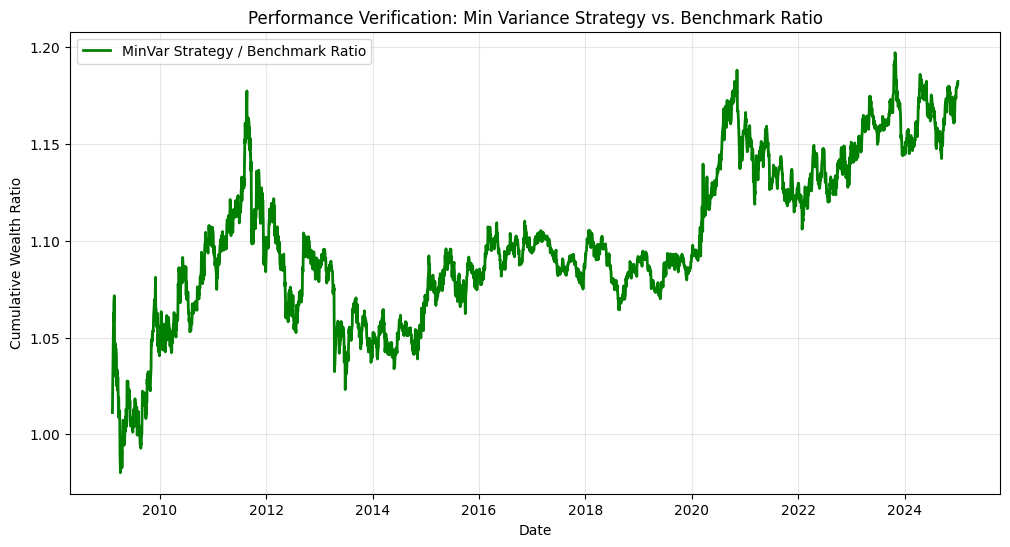

Metric               | MinVar Strategy | Benchmark      
--------------------------------------------------------
Annual Return        | 7.95%          | 6.90%
Annual Volatility    | 13.25%          | 11.64%
Sharpe Ratio         | 0.30             | 0.25
Max Drawdown         | -23.54%          | -26.42%

Allocation during 2022 Crash (Example):
                 QQQ       DBC       XLE       GLD       TLT
2022-06-14  0.226500  0.212770  0.141932  0.418799  0.000000
2022-07-15  0.208459  0.223859  0.148470  0.417428  0.001784
2022-08-15  0.208079  0.233856  0.142136  0.411290  0.004638


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.optimize as sco
import matplotlib.pyplot as plt

# 1. Configuration
# ----------------
# We keep the same assets to make a fair comparison
ASSETS = ['QQQ', 'DBC', 'XLE', 'GLD', 'TLT']
START_DATE = '1990-01-01'
END_DATE = '2025-01-01'

# STRATEGY CHANGE 1: Faster Reaction Time
LOOKBACK_YEARS = 3     # 3 Years lookback (instead of 10 years)

def get_data(assets, start, end):
    data = yf.download(assets, start=start, end=end, auto_adjust=False)['Adj Close']
    returns = np.log(data / data.shift(1)).dropna()
    return returns

# STRATEGY CHANGE 2: Different Objective Function
def portfolio_volatility(weights, cov_matrix):
    """
    Objective: Minimize Portfolio Standard Deviation (Risk).
    We do NOT look at returns here.
    """
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)

def optimize_min_variance(sub_returns):
    num_assets = len(sub_returns.columns)
    cov_matrix = sub_returns.cov()
    
    # args just needs cov_matrix now, not mean_returns
    args = (cov_matrix)
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_guess = num_assets * [1. / num_assets,]
    
    # Minimize Volatility
    result = sco.minimize(portfolio_volatility, init_guess, args=args,
                          method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

# 2. Execution: Walk-Forward Loop
# -------------------------------
print("Fetching Data...")
returns = get_data(ASSETS, START_DATE, END_DATE)

# Rebalance every 21 days (approx 1 month)
start_index = int(LOOKBACK_YEARS * 252)
rebalance_dates = returns.index[start_index::21]

history_weights = []
history_dates = []

print(f"Optimizing for Minimum Variance (Regime: {LOOKBACK_YEARS} yr lookback)...")

for date in rebalance_dates:
    loc = returns.index.get_loc(date)
    window_start = loc - int(LOOKBACK_YEARS * 252)
    if window_start < 0: continue
        
    sub_returns = returns.iloc[window_start:loc]
    
    # Optimize
    opt_weights = optimize_min_variance(sub_returns)
    
    history_weights.append(opt_weights)
    history_dates.append(date)

# 3. Backtest Verification
# ------------------------
weight_df = pd.DataFrame(history_weights, index=history_dates, columns=ASSETS)
daily_weights = weight_df.reindex(returns.index).ffill()
daily_weights = daily_weights.shift(1).dropna() # Shift for causality

aligned_returns = returns.loc[daily_weights.index]

# Strategy Returns
strat_ret = (daily_weights * aligned_returns).sum(axis=1)

# Benchmark (Equal Weight)
bench_ret = aligned_returns.mean(axis=1)

# Cumulative Wealth
strat_cum = np.exp(strat_ret.cumsum())
bench_cum = np.exp(bench_ret.cumsum())
ratio = strat_cum / bench_cum

# 4. Visualization & Stats
# ------------------------


plt.figure(figsize=(12, 6))
plt.plot(ratio, label='MinVar Strategy / Benchmark Ratio', color='green', linewidth=2)
plt.title('Performance Verification: Min Variance Strategy vs. Benchmark Ratio')
plt.ylabel('Cumulative Wealth Ratio')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Stats Table
def get_stats(r):
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (ann_ret - 0.04) / ann_vol 
    max_dd = (np.exp(r.cumsum()) / np.exp(r.cumsum()).cummax() - 1).min()
    return ann_ret, ann_vol, sharpe, max_dd

s_stats = get_stats(strat_ret)
b_stats = get_stats(bench_ret)

print(f"{'Metric':<20} | {'MinVar Strategy':<15} | {'Benchmark':<15}")
print("-" * 56)
print(f"{'Annual Return':<20} | {s_stats[0]:.2%}          | {b_stats[0]:.2%}")
print(f"{'Annual Volatility':<20} | {s_stats[1]:.2%}          | {b_stats[1]:.2%}")
print(f"{'Sharpe Ratio':<20} | {s_stats[2]:.2f}             | {b_stats[2]:.2f}")
print(f"{'Max Drawdown':<20} | {s_stats[3]:.2%}          | {b_stats[3]:.2%}")

# Show allocation during the crash
print("\nAllocation during 2022 Crash (Example):")
print(weight_df.loc['2022-06-01':'2022-09-01'].head(3))

1. Descargando Datos...
2. Ejecutando Optimización Rolling (122 periodos)...


C:\Users\migue\AppData\Local\Temp\ipykernel_20116\1007852871.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = sch.linkage(dist, 'single')
C:\Users\migue\AppData\Local\Temp\ipykernel_20116\1007852871.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = sch.linkage(dist, 'single')
C:\Users\migue\AppData\Local\Temp\ipykernel_20116\1007852871.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = sch.linkage(dist, 'single')
C:\Users\migue\AppData\Local\Temp\ipykernel_20116\1007852871.py:84: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = sch.linkage(dist, 'single')
C:\Users\migue\AppData\Local\Temp\ipykernel_20116\1007852871.py:84: ClusterWarning: 


--- PERFORMANCE METRICS ---
 Ann Return Ann Vol Sharpe Max DD
Strategy    
GMV (Defensivo) 10.26% 24.79% 41.39% -40.76%
MSR (Max Sharpe) 8.42% 22.12% 38.07% -37.16%
HRP (Machine Learning) 11.73% 22.08% 53.12% -35.90%
Benchmark (1/N) 8.64% 22.07% 39.13% -37.12%



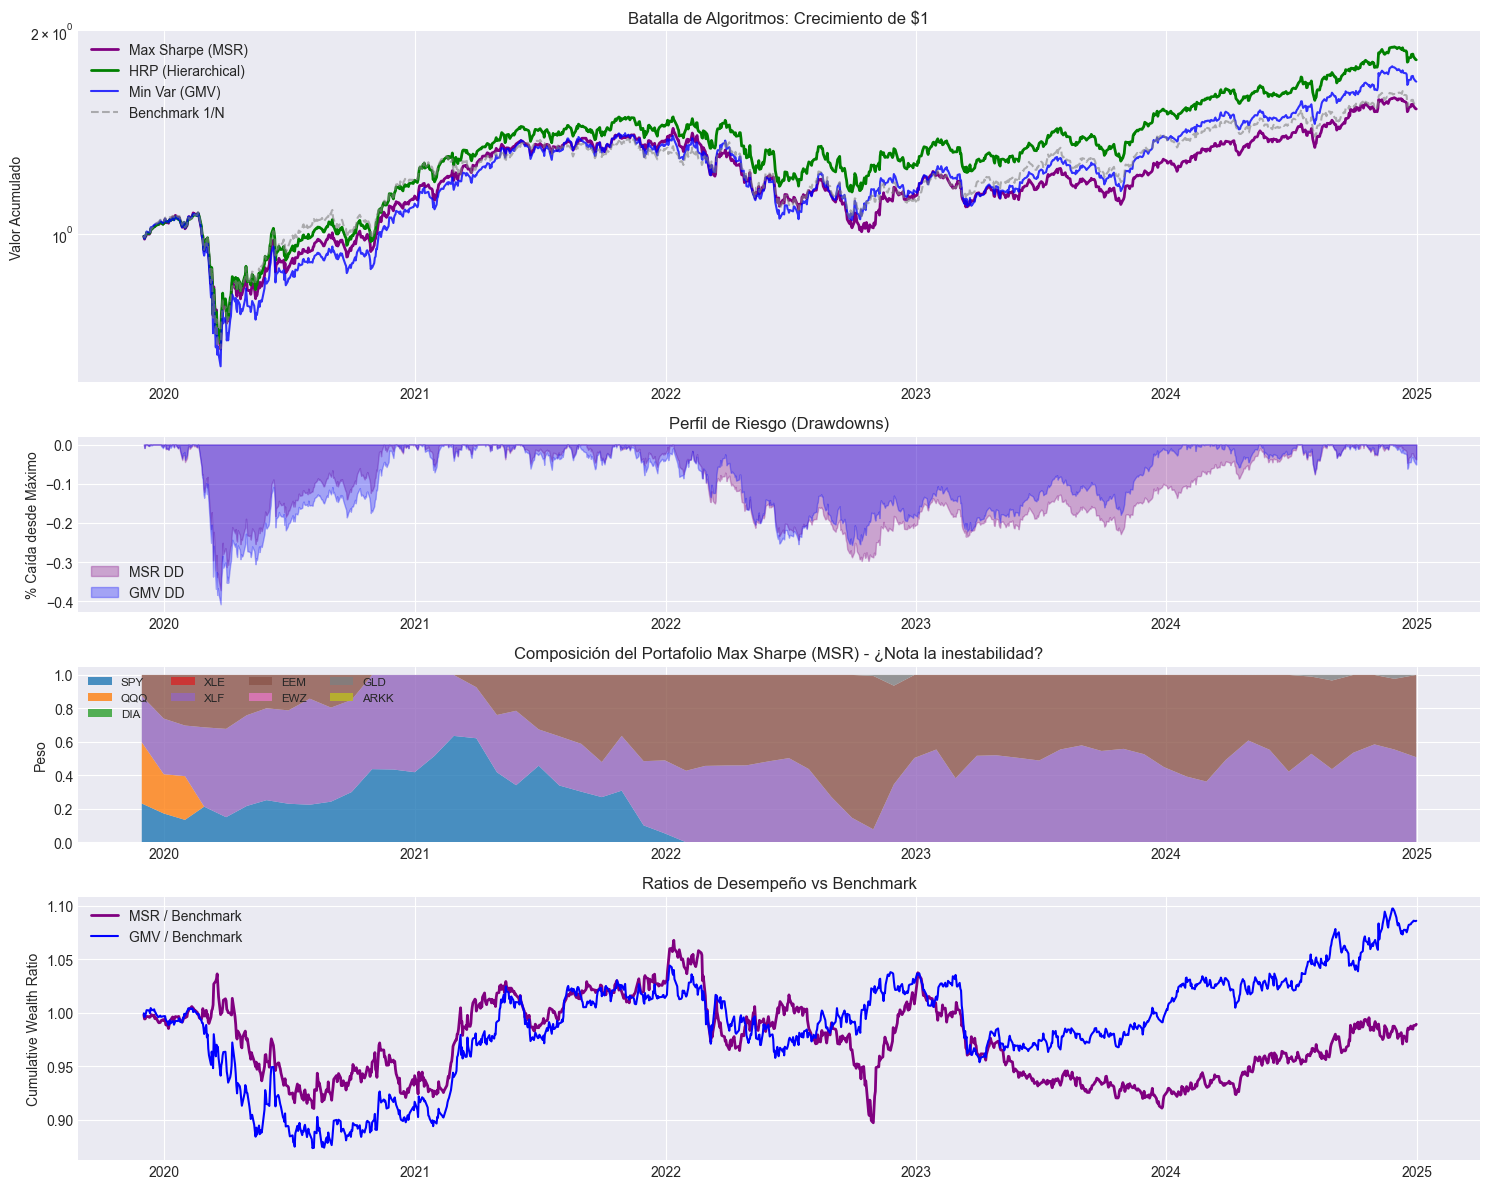

In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.optimize as sco
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import warnings

# Configuración Quant Prof
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Configuración del Universo
# -----------------------------
# Incluimos Bonos Cortos (SHY) como proxy de "Cash" para que los modelos puedan refugiarse
ASSETS = [
    'SPY',  # S&P 500 (Core)
    'QQQ',  # Nasdaq 100 (Tech/Growth)
    'DIA',  # Dow Jones (Value/Industrial)
    'XLE',  # Energy (Inflation Hedge)
    'XLF',  # Financials (Rates Hedge)
    'EEM',  # Emerging Markets (Geo Diversification)
    'EWZ',  # Brasil (Geo Diversification)
    'GLD',  # Oro (Defensive / Crisis Hedge) - EL SUSTITUTO DE LOS BONOS
    'ARKK'  # Innovation (High Beta) - Opcional, muy volátil
]
START_DATE = '1980-01-01' 
END_DATE = '2025-01-01'

# Parámetros de Backtest
LOOKBACK = 252 * 5   # 2 años de memoria
REBALANCE_FREQ = 'ME' # Fin de Mes
TRADING_DAYS = 252

# ==============================================================================
# BLOQUE 1: LOS MOTORES DE OPTIMIZACIÓN
# ==============================================================================

# --- Motor A: Global Minimum Variance (GMV) ---
def get_gmv_weights(cov_matrix):
    num_assets = cov_matrix.shape[0]
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    init_guess = [1. / num_assets] * num_assets
    
    def port_var(w, cov):
        return np.dot(w.T, np.dot(cov, w))
    
    try:
        res = sco.minimize(port_var, init_guess, args=(cov_matrix,),
                           method='SLSQP', bounds=bounds, constraints=constraints, tol=1e-9)
        return res.x
    except:
        return np.array(init_guess)

# --- Motor B: Maximum Sharpe Ratio (MSR) ---
def get_msr_weights(mean_returns, cov_matrix, risk_free_rate):
    num_assets = len(mean_returns)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    init_guess = [1. / num_assets] * num_assets

    def neg_sharpe(w, mean_ret, cov, rf):
        p_ret = np.dot(w, mean_ret) * TRADING_DAYS
        p_vol = np.sqrt(np.dot(w.T, np.dot(cov, w))) * np.sqrt(TRADING_DAYS)
        return - (p_ret - rf) / p_vol # Minimizamos el Sharpe negativo

    try:
        # Nota: Usamos mean_returns históricos (simple). 
        # En producción profesional usaríamos Black-Litterman o Shrinkage.
        res = sco.minimize(neg_sharpe, init_guess, args=(mean_returns, cov_matrix, risk_free_rate),
                           method='SLSQP', bounds=bounds, constraints=constraints, tol=1e-9)
        return res.x
    except:
        return np.array(init_guess)

# --- Motor C: Hierarchical Risk Parity (HRP) ---
def get_hrp_weights(returns_df):
    cov = returns_df.cov()
    corr = returns_df.corr()
    
    # 1. Clustering
    dist = np.sqrt(0.5 * (1 - corr))
    link = sch.linkage(dist, 'single')
    
    # 2. Quasi-Diag (Sort)
    def get_quasi_diag(link):
        link = link.astype(int)
        sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
        num_items = link[-1, 3]
        while sort_ix.max() >= num_items:
            sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
            df0 = sort_ix[sort_ix >= num_items]
            i = df0.index
            j = df0.values - num_items
            sort_ix[i] = link[j, 0]
            df0 = pd.Series(link[j, 1], index=i + 1)
            sort_ix = pd.concat([sort_ix, df0])
            sort_ix = sort_ix.sort_index()
            sort_ix.index = range(sort_ix.shape[0])
        return sort_ix.tolist()
    
    sort_ix = get_quasi_diag(link)
    sort_ix = corr.index[sort_ix].tolist()
    
    # 3. Recursive Bisection
    def get_rec_bisection(cov, sort_ix):
        w = pd.Series(1.0, index=sort_ix)
        c_items = [sort_ix]
        while len(c_items) > 0:
            c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
            for i in range(0, len(c_items), 2):
                c_left = c_items[i]
                c_right = c_items[i + 1]
                # Var cluster
                def get_cluster_var(cov, c):
                    cov_s = cov.loc[c, c]
                    ivp = 1. / np.diag(cov_s)
                    ivp /= ivp.sum()
                    return np.dot(np.dot(ivp.T, cov_s), ivp)
                
                v_left = get_cluster_var(cov, c_left)
                v_right = get_cluster_var(cov, c_right)
                alpha = 1 - v_left / (v_left + v_right)
                w[c_left] *= alpha
                w[c_right] *= 1 - alpha
        return w

    hrp_series = get_rec_bisection(cov, sort_ix)
    return hrp_series.reindex(returns_df.columns).values

# ==============================================================================
# BLOQUE 2: PROCESAMIENTO DE DATOS (AUTO_ADJUST=FALSE)
# ==============================================================================
print("1. Descargando Datos...")
data = yf.download(ASSETS, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)['Adj Close']
log_returns = np.log(data / data.shift(1)).dropna()

# Descarga Risk Free (^TNX) para cálculo de Sharpe
tnx = yf.download("^TNX", start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)['Adj Close']
rf_series_annual = tnx / 100.0
# Rellenar RF faltante
rf_series_annual = rf_series_annual.reindex(log_returns.index).ffill().fillna(0.04)

rebalance_dates = log_returns.resample(REBALANCE_FREQ).last().index

# Almacenamiento
w_gmv, w_msr, w_hrp = [], [], []
valid_dates = []

print(f"2. Ejecutando Optimización Rolling ({len(rebalance_dates)} periodos)...")

for date in rebalance_dates:
    # Índice entero para slicing
    if date not in log_returns.index:
        locs = log_returns.index.get_indexer([date], method='pad')
        if locs[0] == -1: continue
        loc = locs[0]
    else:
        loc = log_returns.index.get_loc(date)
        
    window_start = loc - LOOKBACK
    if window_start < 0: continue
    
    # Ventana de datos (Lookback)
    sub_returns = log_returns.iloc[window_start:loc]
    
    # Datos para MSR
    sub_mean = sub_returns.mean()
    sub_cov = sub_returns.cov()
    # Usamos la Tasa Libre de Riesgo ACTUAL (al momento de la decisión)
    current_rf = rf_series_annual.iloc[loc] 
    
    # --- Ejecutar Modelos ---
    w_gmv.append(get_gmv_weights(sub_cov))
    w_msr.append(get_msr_weights(sub_mean, sub_cov, current_rf))
    w_hrp.append(get_hrp_weights(sub_returns))
    
    valid_dates.append(log_returns.index[loc])

# Crear DataFrames
df_gmv = pd.DataFrame(w_gmv, index=valid_dates, columns=ASSETS)
df_msr = pd.DataFrame(w_msr, index=valid_dates, columns=ASSETS)
df_hrp = pd.DataFrame(w_hrp, index=valid_dates, columns=ASSETS)

# ==============================================================================
# BLOQUE 3: BACKTEST (CAUSALIDAD RIGUROSA)
# ==============================================================================
def run_backtest(weights_df, returns_df):
    # a. Expandir pesos mensuales a diarios
    daily_w = weights_df.reindex(returns_df.index).ffill()
    # b. SHIFT 1 DÍA (Esencial: Pesos de ayer aplican hoy)
    daily_w = daily_w.shift(1).dropna()
    # c. Alinear
    aligned_ret = returns_df.loc[daily_w.index]
    # d. Retorno Simple del Portafolio
    # (Log ret -> Simple ret -> Dot Product -> Log ret)
    simple_ret_assets = np.exp(aligned_ret) - 1
    port_simple = (daily_w * simple_ret_assets).sum(axis=1)
    port_log = np.log(1 + port_simple)
    return port_log

ret_gmv = run_backtest(df_gmv, log_returns)
ret_msr = run_backtest(df_msr, log_returns)
ret_hrp = run_backtest(df_hrp, log_returns)
# Benchmark Equi-weighted (1/N)
ret_bench = log_returns.mean(axis=1).loc[ret_gmv.index]

# ==============================================================================
# BLOQUE 4: RESULTADOS Y VISUALIZACIÓN
# ==============================================================================
cum_gmv = np.exp(ret_gmv.cumsum())
cum_msr = np.exp(ret_msr.cumsum())
cum_hrp = np.exp(ret_hrp.cumsum())
cum_bench = np.exp(ret_bench.cumsum())

def get_stats(r, name):
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    dd = (np.exp(r.cumsum()) / np.exp(r.cumsum()).cummax() - 1).min()
    return [name, ann_ret, ann_vol, sharpe, dd]

stats_data = [
    get_stats(ret_gmv, "GMV (Defensivo)"),
    get_stats(ret_msr, "MSR (Max Sharpe)"),
    get_stats(ret_hrp, "HRP (Machine Learning)"),
    get_stats(ret_bench, "Benchmark (1/N)")
]

stats_df = pd.DataFrame(stats_data, columns=['Strategy', 'Ann Return', 'Ann Vol', 'Sharpe', 'Max DD'])
stats_df.set_index('Strategy', inplace=True)

print("\n--- PERFORMANCE METRICS ---")
print(stats_df.style.format("{:.2%}").format_index(str, axis=0).to_string())

# Gráficas
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(4, 1, height_ratios=[2, 1, 1, 1.5])

# 1. Curvas de Equidad
ax1 = fig.add_subplot(gs[0])
ax1.plot(cum_msr, label='Max Sharpe (MSR)', color='purple', linewidth=2)
ax1.plot(cum_hrp, label='HRP (Hierarchical)', color='green', linewidth=2)
ax1.plot(cum_gmv, label='Min Var (GMV)', color='blue', linewidth=1.5, alpha=0.8)
ax1.plot(cum_bench, label='Benchmark 1/N', color='gray', linestyle='--', alpha=0.6)
ax1.set_title('Batalla de Algoritmos: Crecimiento de $1')
ax1.set_ylabel('Valor Acumulado')
ax1.set_yscale('log')
ax1.legend()

# 2. Drawdowns
ax2 = fig.add_subplot(gs[1], sharex=ax1)
def plot_dd(r, color, lbl):
    dd = (np.exp(r.cumsum()) / np.exp(r.cumsum()).cummax() - 1)
    ax2.fill_between(dd.index, dd, 0, color=color, alpha=0.3, label=lbl)
plot_dd(ret_msr, 'purple', 'MSR DD')
plot_dd(ret_gmv, 'blue', 'GMV DD')
ax2.set_title('Perfil de Riesgo (Drawdowns)')
ax2.set_ylabel('% Caída desde Máximo')
ax2.legend()

# 3. Pesos Dinámicos (Solo mostramos MSR para ver la agresividad)
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.stackplot(df_msr.index, df_msr.T, labels=df_msr.columns, alpha=0.8)
ax3.set_title('Composición del Portafolio Max Sharpe (MSR) - ¿Nota la inestabilidad?')
ax3.set_ylabel('Peso')
ax3.legend(loc='upper left', fontsize='small', ncol=4)

#4. Ratios
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ratio_msr = cum_msr / cum_bench
ratio_gmv = cum_gmv / cum_bench
ax4.plot(ratio_msr, label='MSR / Benchmark', color='purple', linewidth=2)
ax4.plot(ratio_gmv, label='GMV / Benchmark', color='blue', linewidth=1.5)
ax4.set_title('Ratios de Desempeño vs Benchmark')
ax4.set_ylabel('Cumulative Wealth Ratio')
ax4.legend()

plt.tight_layout()
plt.show()


--- PERFORMANCE METRICS ---
 Ann Return Ann Vol Sharpe Max DD
Strategy    
GMV (Defensivo) 11.02% 23.26% 47.37% -40.86%
MSR (Max Sharpe) 10.59% 21.35% 49.62% -39.48%
HRP (Machine Learning) 10.42% 20.98% 49.66% -38.02%
Benchmark (1/N) 8.27% 20.35% 40.64% -37.12%



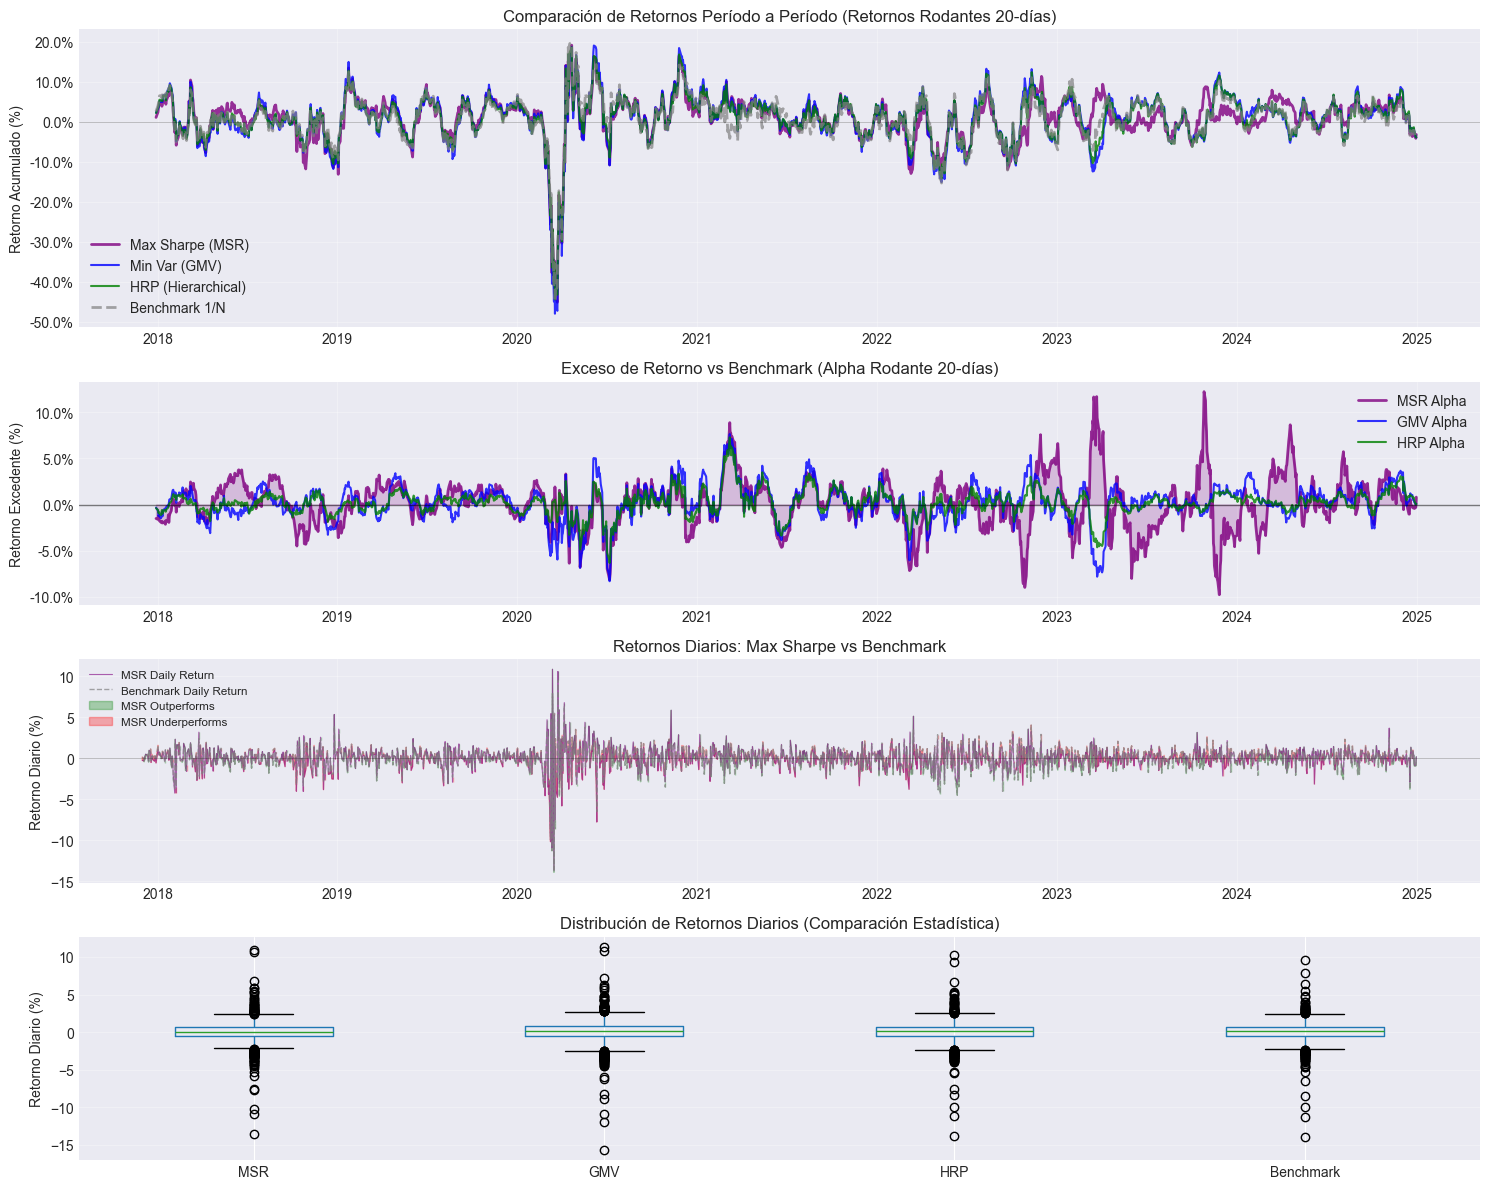


--- WIN RATE vs BENCHMARK ---
MSR Win Rate: 50.4%
GMV Win Rate: 51.2%
HRP Win Rate: 50.7%


In [6]:
# ==============================================================================
# BLOQUE 4: RESULTADOS Y VISUALIZACIÓN
# ==============================================================================
cum_gmv = np.exp(ret_gmv.cumsum())
cum_msr = np.exp(ret_msr.cumsum())
cum_hrp = np.exp(ret_hrp.cumsum())
cum_bench = np.exp(ret_bench.cumsum())

def get_stats(r, name):
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol
    dd = (np.exp(r.cumsum()) / np.exp(r.cumsum()).cummax() - 1).min()
    return [name, ann_ret, ann_vol, sharpe, dd]

stats_data = [
    get_stats(ret_gmv, "GMV (Defensivo)"),
    get_stats(ret_msr, "MSR (Max Sharpe)"),
    get_stats(ret_hrp, "HRP (Machine Learning)"),
    get_stats(ret_bench, "Benchmark (1/N)")
]

stats_df = pd.DataFrame(stats_data, columns=['Strategy', 'Ann Return', 'Ann Vol', 'Sharpe', 'Max DD'])
stats_df.set_index('Strategy', inplace=True)

print("\n--- PERFORMANCE METRICS ---")
print(stats_df.style.format("{:.2%}").format_index(str, axis=0).to_string())

# Gráficas
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(4, 1, height_ratios=[2, 1.5, 1.5, 1.5])

# 1. COMPARACIÓN DE RETORNOS PERÍODO A PERÍODO (Rolling 20-day returns)
ax1 = fig.add_subplot(gs[0])
window = 20  # Retornos rodantes de 20 días
rolling_ret_msr = ret_msr.rolling(window).sum()
rolling_ret_gmv = ret_gmv.rolling(window).sum()
rolling_ret_hrp = ret_hrp.rolling(window).sum()
rolling_ret_bench = ret_bench.rolling(window).sum()

ax1.plot(rolling_ret_msr, label='Max Sharpe (MSR)', color='purple', linewidth=2, alpha=0.8)
ax1.plot(rolling_ret_gmv, label='Min Var (GMV)', color='blue', linewidth=1.5, alpha=0.8)
ax1.plot(rolling_ret_hrp, label='HRP (Hierarchical)', color='green', linewidth=1.5, alpha=0.8)
ax1.plot(rolling_ret_bench, label='Benchmark 1/N', color='gray', linestyle='--', linewidth=2, alpha=0.7)
ax1.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax1.set_title(f'Comparación de Retornos Período a Período (Retornos Rodantes {window}-días)')
ax1.set_ylabel('Retorno Acumulado (%)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# 2. EXCESO DE RETORNO vs BENCHMARK (Alpha)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
alpha_msr = ret_msr - ret_bench
alpha_gmv = ret_gmv - ret_bench
alpha_hrp = ret_hrp - ret_bench

ax2.plot(alpha_msr.rolling(window).sum(), label='MSR Alpha', color='purple', linewidth=2, alpha=0.8)
ax2.plot(alpha_gmv.rolling(window).sum(), label='GMV Alpha', color='blue', linewidth=1.5, alpha=0.8)
ax2.plot(alpha_hrp.rolling(window).sum(), label='HRP Alpha', color='green', linewidth=1.5, alpha=0.8)
ax2.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.fill_between(alpha_msr.index, 0, alpha_msr.rolling(window).sum(), alpha=0.2, color='purple')
ax2.set_title(f'Exceso de Retorno vs Benchmark (Alpha Rodante {window}-días)')
ax2.set_ylabel('Retorno Excedente (%)')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# 3. RETORNOS DIARIOS COMPARADOS (Scatter/Line)
ax3 = fig.add_subplot(gs[2], sharex=ax1)
# Mostrar retornos diarios de las estrategias vs el benchmark
ax3.plot(ret_msr.index, ret_msr * 100, label='MSR Daily Return', color='purple', linewidth=0.8, alpha=0.6)
ax3.plot(ret_bench.index, ret_bench * 100, label='Benchmark Daily Return', color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax3.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax3.fill_between(ret_msr.index, ret_msr * 100, ret_bench * 100, 
                  where=(ret_msr >= ret_bench), alpha=0.3, color='green', label='MSR Outperforms')
ax3.fill_between(ret_msr.index, ret_msr * 100, ret_bench * 100, 
                  where=(ret_msr < ret_bench), alpha=0.3, color='red', label='MSR Underperforms')
ax3.set_title('Retornos Diarios: Max Sharpe vs Benchmark')
ax3.set_ylabel('Retorno Diario (%)')
ax3.legend(loc='best', fontsize='small')
ax3.grid(True, alpha=0.3)

# 4. DISTRIBUCIÓN DE RETORNOS (Comparison Box Plot)
ax4 = fig.add_subplot(gs[3])
returns_comparison = pd.DataFrame({
    'MSR': ret_msr * 100,
    'GMV': ret_gmv * 100,
    'HRP': ret_hrp * 100,
    'Benchmark': ret_bench * 100
})
returns_comparison.boxplot(ax=ax4)
ax4.set_title('Distribución de Retornos Diarios (Comparación Estadística)')
ax4.set_ylabel('Retorno Diario (%)')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Tabla de comparación adicional: Win Rate (% de días ganando)
print("\n--- WIN RATE vs BENCHMARK ---")
win_rate_msr = (ret_msr > ret_bench).sum() / len(ret_msr) * 100
win_rate_gmv = (ret_gmv > ret_bench).sum() / len(ret_gmv) * 100
win_rate_hrp = (ret_hrp > ret_bench).sum() / len(ret_hrp) * 100

print(f"MSR Win Rate: {win_rate_msr:.1f}%")
print(f"GMV Win Rate: {win_rate_gmv:.1f}%")
print(f"HRP Win Rate: {win_rate_hrp:.1f}%")

HRP